# Deep Learning Systems
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Exploration and Preprocessing](#prep)
- [Base Model Implementation and Training](#base)
- [Experimental Model Implementation and Training](#exper)
- [Model Evaluation](#eval)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we implement a deep learning experiment workflow, where we try to forecast financial timeseries obtained from Yahoo Finance (https://finance.yahoo.com). We will focus on daily close values for the SPX, an equity index consisting of 500 large US companies, and the VIX, an index that measures the (market expectations on the) volatility of the SPX index. Our goal is to forecast the daily close value for these indices on a given day from the timeseries up to that day.

We start by loading and preparing the data. We then implement and train a recurrent neural network using LSTM layers as a base model, as well as an experimental model using linear layers and ReLU activation. We evaluate the performance of both models on training and test data, before concluding with a short summary of our findings.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip3 install torch torchvision

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# We set a fixed seed of the random generator for better reprodicibility, see
# https://docs.pytorch.org/docs/stable/notes/randomness.html#reproducibility
torch.manual_seed(0);

In [5]:
# Note: The timeseries have already been downloaded and are stored in the spx.csv and vix.csv files in this project.
# By setting the below variable to true, they can be reloaded from Yahoo Finance
reload_data_imports = False
if(reload_data_imports):
    !pip install yfinance # Note: The yfinance package is not included in the requirements.txt and has to be installed here
    import yfinance as yf
    df_vix = yf.download(tickers=["^SPX"], start='2006-04-15', end='2026-04-15')
    df_vix.columns = ['Close','High','Low','Open','Volume']
    df_vix.to_csv('./spx.csv')
    df_vix = yf.download(tickers=["^VIX"], start='2006-04-15', end='2026-04-15')
    df_vix.columns = ['Close','High','Low','Open','Volume']
    df_vix.to_csv('./vix.csv')

In [6]:
df_spx = pd.read_csv("spx.csv")
df_vix = pd.read_csv("vix.csv")

In [7]:
df_spx.head()

,Date,Close,High,Low,Open,Volume
0,2006-04-17,1285.329956,1292.449951,1280.739990,1289.119995,1794650000
1,2006-04-18,1307.280029,1309.020020,1285.329956,1285.329956,2595440000
2,2006-04-19,1309.930054,1310.390015,1302.790039,1307.650024,2447310000
3,2006-04-20,1311.459961,1318.160034,1306.380005,1309.930054,2512920000
4,2006-04-21,1311.280029,1317.670044,1306.589966,1311.459961,2392630000


In [8]:
df_vix.head()

,Date,Close,High,Low,Open,Volume
0,2006-04-17,12.58,13.02,12.27,12.80,0
1,2006-04-18,11.40,12.55,11.31,12.55,0
2,2006-04-19,11.32,11.80,11.23,11.52,0
3,2006-04-20,11.64,11.67,11.02,11.30,0
4,2006-04-21,11.59,11.98,11.19,11.24,0


<a id='prep'></a>
### Data Exploration and Preprocessing

In this section, we explore the data and perform some cleaning and rescaling steps.

In [9]:
df_spx.info()

<class 'pandas.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5030 non-null   str    
 1   Close   5030 non-null   float64
 2   High    5030 non-null   float64
 3   Low     5030 non-null   float64
 4   Open    5030 non-null   float64
 5   Volume  5030 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 235.9 KB


In [10]:
df_vix.info()

<class 'pandas.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5030 non-null   str    
 1   Close   5030 non-null   float64
 2   High    5030 non-null   float64
 3   Low     5030 non-null   float64
 4   Open    5030 non-null   float64
 5   Volume  5030 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 235.9 KB


There are no missing values in either timeseries. We will next drop columns that are not required in our workflow and tidy the date column.

In [11]:
df_spx.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
df_spx.Date = pd.to_datetime(df_spx.Date)
df_vix.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
df_vix.Date = pd.to_datetime(df_vix.Date)

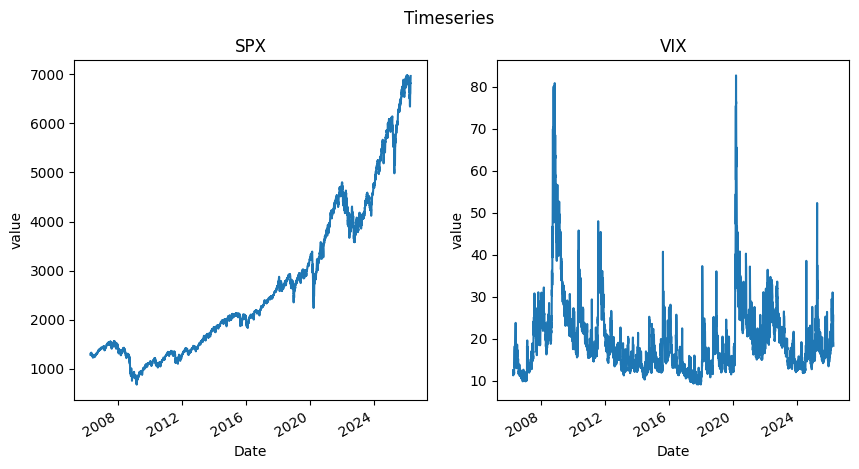

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Timeseries')
df_spx.plot(x='Date', y='Close', ax=ax[0]);
df_vix.plot(x='Date', y='Close', ax=ax[1]);
ax[0].set(title='SPX', ylabel='value')
ax[1].set(title='VIX', ylabel='value')
ax[0].get_legend().remove()
ax[1].get_legend().remove()
plt.show()

In [13]:
np.corrcoef(df_spx.Close, df_vix.Close)[0,1]

np.float64(-0.14678070925544792)

As one can see in the above plots, the timeseries for SPX and VIX have a very different qualitative behaviour: The SPX index has a clear positive trend and a moderate variance, while the VIX index is mean-reverting to a level of around 20% and has a high variance. It is also worth mentioning that SPX and VIX are somewhat negatively correlated, i.e. in market stress the SPX goes down and the VIX goes up (as can be seen in the above plots e.g. in the financial crisis 2008 and the covid crisis 2020), and vice versa in boom phases.

In [14]:
df_spx.Close.describe()

count    5030.000000
mean     2680.589053
std      1571.951612
min       676.530029
25%      1387.900055
50%      2102.789917
75%      3823.702393
max      6978.600098
Name: Close, dtype: float64

In [15]:
df_vix.Close.describe()

count    5030.000000
mean       19.583278
std         8.707569
min         9.140000
25%        13.860000
50%        17.240000
75%        22.559999
max        82.690002
Name: Close, dtype: float64

We next need to prepare the data. First, SPX and VIX are positive quantities by definition. Hence we prefer to work on the logarithm of their close values to ensure positivity. We also rescale them to zero mean, and split them 80/20 into training and test data. Note that the we use the most recent part of the series as test data, which is in line with the requirements for a productive model.

In [16]:
def split_scale_df(df):
    '''
    A function that rescales a dataframe and splits into training and test set.
    
    Args:
        df (dataframe): The Pandas dataframe
        
    Returns:
        (dataframe, dataframe, float): The dataframes for training and test data, 
                                        as well as the mean of the log-close on the training data                                    
    '''
    n_df = len(df.index)
    df_train = df.loc[:0.8*n_df].copy()
    df_train['LogClose'] = df_train.apply(lambda row: np.log(row['Close']), axis=1)
    mean_logclose = df_train['LogClose'].mean()
    df_train['LogClose'] = df_train.apply(lambda row: row['LogClose']-mean_logclose, axis=1)
    df_test = df.loc[0.8*n_df:].copy()
    df_test['LogClose'] = df_test.apply(lambda row: np.log(row['Close']), axis=1)
    df_test['LogClose'] = df_test.apply(lambda row: row['LogClose']-mean_logclose, axis=1)
    return (df_train, df_test, mean_logclose)

In [17]:
(df_train_spx, df_test_spx, mean_spx) = split_scale_df(df_spx)
(df_train_vix, df_test_vix, mean_vix) = split_scale_df(df_vix)

Next, we need to split the data into windows used for the prediction of the next value, and define the window size. In order to get an idea for the latter, we look at the autocorrelations of both indices:

In [18]:
autocorr_spx = pd.DataFrame([[l,df_spx.Close.autocorr(lag=l)] for l in range(200)])
autocorr_spx.columns = ['lag','corr']
autocorr_vix = pd.DataFrame([[l,df_vix.Close.autocorr(lag=l)] for l in range(200)])
autocorr_vix.columns = ['lag','corr']

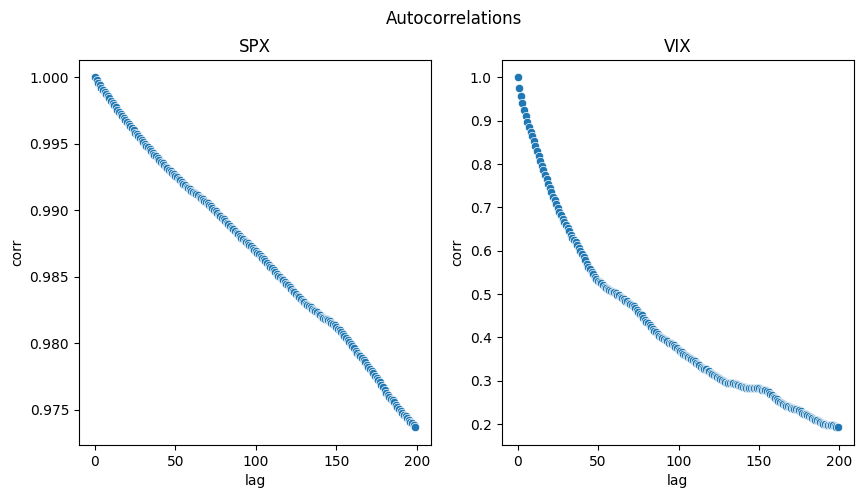

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Autocorrelations')
sns.scatterplot(autocorr_spx,x='lag',y='corr', ax=ax[0]);
sns.scatterplot(autocorr_vix,x='lag',y='corr', ax=ax[1]);
ax[0].set(title='SPX')
ax[1].set(title='VIX')
plt.show()

The autocorrelations also exhibit a very different behaviour for SPX and VIX: While autocorrelation decays rather slowly for the trending SPX, where it is still above 97% after 200 days, it decays much faster for the mean-reverting VIX and is only at around 20% after 200 days.

For simplicity, we use a single window size for both indices, and we set it to 20 days, where the autocorrelation of the VIX has decayed to around 70%. We now do the window splitting and transform our data to torch tensors.

In [20]:
window_size = 20

In [21]:
def split_windows(values, window_size):
    '''
    A function that splits a timeseries into a series of feature windows and 
    a series of continuations of these windows with the next value
    
    Args:
        values (numpy array): The timeseries to split
        window_size (int): The length of the windows
        
    Returns:
        (numpy array, numpy array): The series of feature windows and the series of continuations                                    
    '''
    windows = []
    continuations = []
    for i in range(len(values) - window_size-1):
        windows.append(values[i : i + window_size])
        continuations.append(values[i + window_size])
    windows = np.array(windows, dtype=np.float32)
    continuations = np.array(continuations, dtype=np.float32)
    return (windows, continuations)

In [22]:
(windows_train_spx, labels_train_spx) = split_windows(df_train_spx[['LogClose']].to_numpy(), window_size)
x_train_spx = torch.tensor(windows_train_spx)
y_train_spx = torch.tensor(labels_train_spx)

(windows_test_spx, labels_test_spx) = split_windows(df_test_spx[['LogClose']].to_numpy(), window_size)
x_test_spx = torch.tensor(windows_test_spx)
y_test_spx = torch.tensor(labels_test_spx)

In [23]:
(windows_train_vix, labels_train_vix) = split_windows(df_train_vix[['LogClose']].to_numpy(), window_size)
x_train_vix = torch.tensor(windows_train_vix)
y_train_vix = torch.tensor(labels_train_vix)

(windows_test_vix, labels_test_vix) = split_windows(df_test_vix[['LogClose']].to_numpy(), window_size)
x_test_vix = torch.tensor(windows_test_vix)
y_test_vix = torch.tensor(labels_test_vix)

In [24]:
print(x_train_vix.shape)
print(y_train_vix.shape)

torch.Size([4004, 20, 1])
torch.Size([4004, 1])


We finally need to implemented torch objects for storing and loading the data, which are required to run the model training:

In [25]:
class MyDataset(Dataset):
    '''
    A class that implements the abstract torch Dataset class.
    It wraps the data and is to be used as input for the DataLoader.
    '''
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [26]:
dataset_train_spx = MyDataset(x_train_spx, y_train_spx)
loader_train_spx = DataLoader(dataset_train_spx, batch_size=32, shuffle=True)
dataset_test_spx = MyDataset(x_test_spx, y_test_spx)
loader_test_spx = DataLoader(dataset_test_spx, batch_size=32, shuffle=False)

In [27]:
dataset_train_vix = MyDataset(x_train_vix, y_train_vix)
loader_train_vix = DataLoader(dataset_train_vix, batch_size=32, shuffle=True)
dataset_test_vix = MyDataset(x_test_vix, y_test_vix)
loader_test_vix = DataLoader(dataset_test_vix, batch_size=32, shuffle=False)

<a id='base'></a>
### Base Model Implementation and Training

We first set some global parameters and implement a function for model training.

In [28]:
learn_rate = 0.0005
epochs = 10
criterion = nn.MSELoss()

In [29]:
def train_model(model, optimizer, loader_train, loader_test, epochs):
    '''
    A function performs the model training and logs the loss functions
    
    Args:
        model (nn.Module): The model to train
        optimizer (int): Torch optimizer used in training
        loader_train (DataLoader): Loader for batched training data
        loader_test (DataLoader): Loader for batched test data
        epochs (int): Epochs to run for training
        
    Returns:
        (array, array): The loss functions for training and test data                                    
    '''
    train_losses, test_losses = [], []
    for e in range(epochs):
        running_loss = 0
        for windows, continuations in loader_train:
            windows = windows.to(device)
            continuations = continuations.to(device)
            optimizer.zero_grad()
            predictions = model.forward(windows)
            loss = criterion(predictions, continuations)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        else:
            test_loss = 0
            accuracy = 0
            with torch.no_grad():
                model.eval()
                for windows, continuations in loader_test:
                    windows = windows.to(device)
                    continuations = continuations.to(device)
                    
                    predictions = model(windows)
                    test_loss += criterion(predictions, continuations).item()
            model.train()
            
            train_losses.append(running_loss/len(loader_train))
            test_losses.append(test_loss/len(loader_test))
    
            print("Epoch: {}/{}.. ".format(e+1, epochs),
                  "Training Loss: {:.3f}.. ".format(running_loss/len(loader_train)),
                  "Test Loss: {:.3f}.. ".format(test_loss/len(loader_test))
            )
    return (train_losses, test_losses)

Now we define and train our base model using two LSTM layers and a linear layer contracting the network to feature dimension. Morew precisely, we define a separate base model for SPX and for VIX.

In [30]:
class ExtractTensor(nn.Module):
    '''
    The LSTM output has shape shape (batch, features, hidden).
    We need to remove the hidden output for further use with a linear layer in a sequential model.
    The required dimensionality reduction is implemented in this class
    '''
    def forward(self,x):
        # Output shape (batch, features, hidden)
        tensor, _ = x
        # Reshape shape (batch, hidden)
        return tensor[:, -1, :]

In [31]:
model_base_spx = nn.Sequential(
    nn.LSTM(x_train_spx.shape[2], 256, num_layers=2), 
    ExtractTensor(),
    nn.Linear(256, x_train_spx.shape[2])
).to(device)
optimizer_base_spx = optim.Adam(model_base_spx.parameters(), lr=learn_rate)

In [32]:
(train_losses_base_spx, test_losses_base_spx) = train_model(model_base_spx, optimizer_base_spx, loader_train_spx, loader_test_spx, epochs)

Epoch: 1/10..  Training Loss: 0.086..  Test Loss: 0.009.. 
Epoch: 2/10..  Training Loss: 0.002..  Test Loss: 0.004.. 
Epoch: 3/10..  Training Loss: 0.001..  Test Loss: 0.003.. 
Epoch: 4/10..  Training Loss: 0.001..  Test Loss: 0.002.. 
Epoch: 5/10..  Training Loss: 0.000..  Test Loss: 0.002.. 
Epoch: 6/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 7/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 8/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 9/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 10/10..  Training Loss: 0.000..  Test Loss: 0.000.. 


In [33]:
model_base_vix = nn.Sequential(
    nn.LSTM(x_train_vix.shape[2], 256, num_layers=2), 
    ExtractTensor(),
    nn.Linear(256, x_train_vix.shape[2])
).to(device)
optimizer_base_vix = optim.Adam(model_base_vix.parameters(), lr=learn_rate)

In [34]:
(train_losses_base_vix, test_losses_base_vix) = train_model(model_base_vix, optimizer_base_vix, loader_train_vix, loader_test_vix, epochs)

Epoch: 1/10..  Training Loss: 0.068..  Test Loss: 0.006.. 
Epoch: 2/10..  Training Loss: 0.007..  Test Loss: 0.006.. 
Epoch: 3/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 4/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 5/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 6/10..  Training Loss: 0.006..  Test Loss: 0.005.. 
Epoch: 7/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 8/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 9/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 10/10..  Training Loss: 0.006..  Test Loss: 0.006.. 


We finally calculate predictions and errors on the test set for usage in the evaluation section.

In [35]:
act_spx = np.exp(y_test_spx.detach().cpu().numpy()+mean_spx)
pred_base_spx = model_base_spx.forward(x_test_spx).detach().cpu().numpy()
pred_base_spx= np.exp(pred_base_spx+mean_spx)
diff_base_spx = pred_base_spx-act_spx

In [36]:
act_vix = np.exp(y_test_vix.detach().cpu().numpy()+mean_vix)
pred_base_vix = model_base_vix.forward(x_test_vix).detach().cpu().numpy()
pred_base_vix= np.exp(pred_base_vix+mean_vix)
diff_base_vix = pred_base_vix-act_vix

<a id='exper'></a>
### Experimental Model Implementation and Training

In this section, we define and train an experimental model using only linear layers and ReLU activation functions. The workflow is the same as for the base model.

In [37]:
model_exp_spx = nn.Sequential(
    nn.Flatten(start_dim=1), # Note: The feature dimension in the input is specific for LSTM layers, so we need to flatten first
    nn.Linear(x_train_spx.shape[1]*x_train_spx.shape[2], 128), 
    nn.ReLU(), 
    nn.Linear(128,64), 
    nn.ReLU(), 
    nn.Linear(64, x_train_spx.shape[2])
).to(device)
optimizer_exp_spx = optim.Adam(model_exp_spx.parameters(), lr=learn_rate)

In [38]:
(train_losses_exp_spx, test_losses_exp_spx) = train_model(model_exp_spx, optimizer_exp_spx, loader_train_spx, loader_test_spx, epochs)

Epoch: 1/10..  Training Loss: 0.020..  Test Loss: 0.002.. 
Epoch: 2/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 3/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 4/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 5/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 6/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 7/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 8/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 9/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 10/10..  Training Loss: 0.000..  Test Loss: 0.001.. 


In [39]:
model_exp_vix = nn.Sequential(
    nn.Flatten(start_dim=1), 
    nn.Linear(x_train_vix.shape[1]*x_train_vix.shape[2], 128), 
    nn.ReLU(), 
    nn.Linear(128,64), 
    nn.ReLU(), 
    nn.Linear(64, x_train_vix.shape[2])
).to(device)
optimizer_exp_vix = optim.Adam(model_exp_vix.parameters(), lr=learn_rate)

In [40]:
(train_losses_exp_vix, test_losses_exp_vix) = train_model(model_exp_vix, optimizer_exp_vix, loader_train_vix, loader_test_vix, epochs)

Epoch: 1/10..  Training Loss: 0.024..  Test Loss: 0.008.. 
Epoch: 2/10..  Training Loss: 0.008..  Test Loss: 0.007.. 
Epoch: 3/10..  Training Loss: 0.007..  Test Loss: 0.006.. 
Epoch: 4/10..  Training Loss: 0.006..  Test Loss: 0.007.. 
Epoch: 5/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 6/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 7/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 8/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 9/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 10/10..  Training Loss: 0.006..  Test Loss: 0.006.. 


In [41]:
pred_exp_spx = model_exp_spx.forward(x_test_spx).detach().cpu().numpy()
pred_exp_spx = np.exp(pred_exp_spx+mean_spx)
diff_exp_spx = pred_exp_spx-act_spx

In [42]:
pred_exp_vix = model_exp_vix.forward(x_test_vix).detach().cpu().numpy()
pred_exp_vix = np.exp(pred_exp_vix+mean_vix)
diff_exp_vix = pred_exp_vix-act_vix

<a id='eval'></a>
### Model Evaluation

In this section, we evaluate the performance of our model. Let us first plot the training and test losses, showing that training reached a minimum for all models:

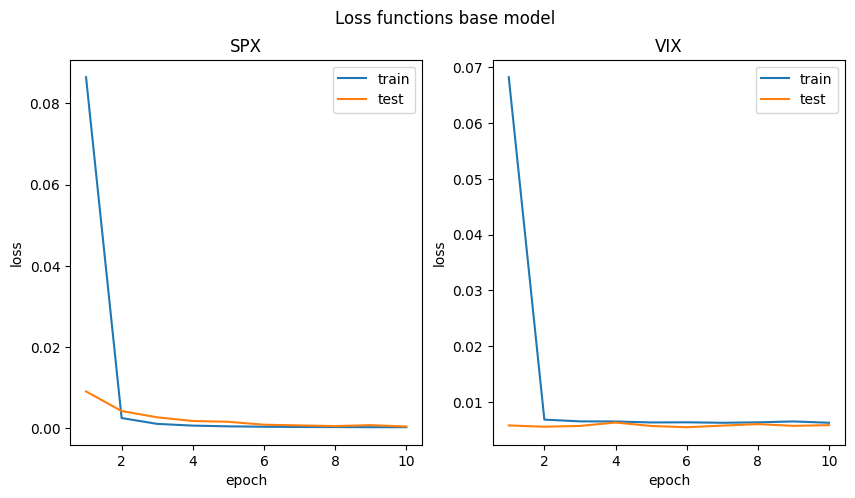

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Loss functions base model')
ax[0].plot(range(1,epochs+1), train_losses_base_spx, label="train")
ax[0].plot(range(1,epochs+1), test_losses_base_spx, label="test")
ax[1].plot(range(1,epochs+1), train_losses_base_vix, label="train")
ax[1].plot(range(1,epochs+1), test_losses_base_vix, label="test")
ax[0].set(title='SPX', xlabel='epoch', ylabel='loss')
ax[1].set(title='VIX', xlabel='epoch', ylabel='loss')
ax[0].legend(loc="upper right")
ax[1].legend(loc="upper right")
plt.show()

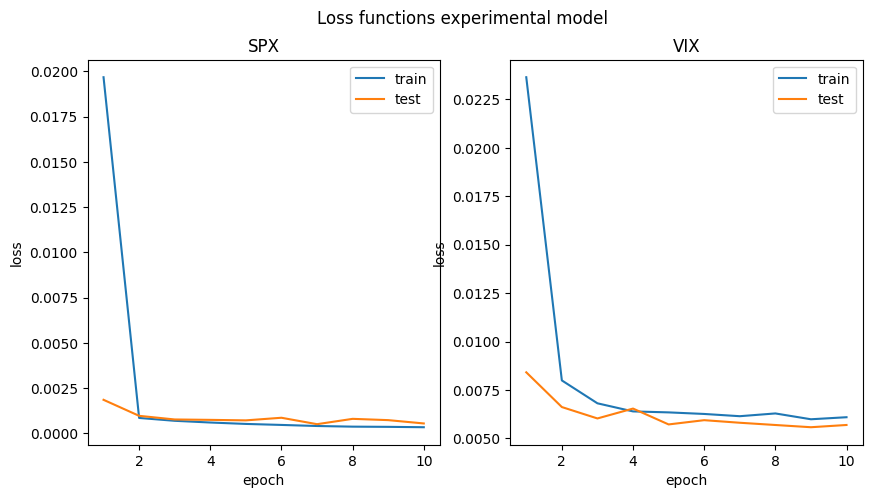

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Loss functions experimental model')
ax[0].plot(range(1,epochs+1), train_losses_exp_spx, label="train")
ax[0].plot(range(1,epochs+1), test_losses_exp_spx, label="test")
ax[1].plot(range(1,epochs+1), train_losses_exp_vix, label="train")
ax[1].plot(range(1,epochs+1), test_losses_exp_vix, label="test")
ax[0].set(title='SPX', xlabel='epoch', ylabel='loss')
ax[1].set(title='VIX', xlabel='epoch', ylabel='loss')
ax[0].legend(loc="upper right")
ax[1].legend(loc="upper right")
plt.show()

We next look at the relative errors for predictions versus actual realizations on the test set:

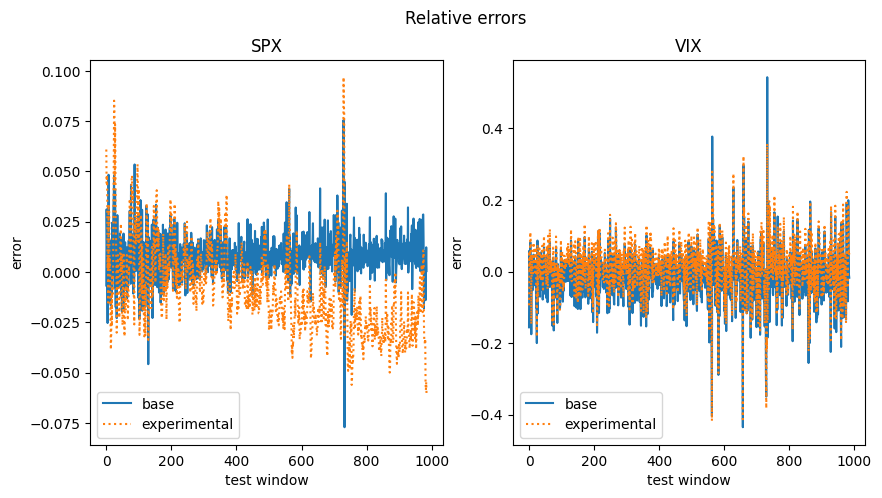

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Relative errors')
ax[0].plot(diff_base_spx/act_spx, label="base")
ax[0].plot(diff_exp_spx/act_spx,linestyle='dotted', label="experimental")
ax[1].plot(diff_base_vix/act_vix, label="base")
ax[1].plot(diff_exp_vix/act_vix,linestyle='dotted', label="experimental")
ax[0].set(title='SPX', xlabel='test window', ylabel='error')
ax[1].set(title='VIX', xlabel='test window', ylabel='error')
ax[0].legend(loc="lower left")
ax[1].legend(loc="lower left")
plt.show()

We finally compute the mean absolute value of relative errors on the test set for each model:

In [46]:
print('SPX:')
print(f'Mean abs of relative errors base: {np.mean(np.abs(pred_base_spx/act_spx-1))}')
print(f'Mean abs of relative errors exp: {np.mean(np.abs(pred_exp_spx/act_spx-1))}')
print('VIX:')
print(f'Mean abs of relative errors base: {np.mean(np.abs(pred_base_vix/act_vix-1))}')
print(f'Mean abs of relative errors exp: {np.mean(np.abs(pred_exp_vix/act_vix-1))}')

SPX:
Mean abs of relative errors base: 0.011081948580269193
Mean abs of relative errors exp: 0.019092027499141812
VIX:
Mean abs of relative errors base: 0.050587572261860746
Mean abs of relative errors exp: 0.05361910131912839


<a id='summary'></a>
### Summary

We have implemented two models to forecast the value for the SPX and VIX indices, given a window of the last 20 daily values. The base model is a recurrent neural network using two LSTM layers, while the experimental model uses linear layers and ReLU activation. Training and evaluating the models gave the following results:
- Model training converged for all models after ten epochs.
- For the SPX index, the base model shows a better performance with mean absolute value of relative errors around 1%, while the experimental model has 2%.
- For the VIX index, both models perform much worse than for the SPX, with mean absolute value of relative errors around 5%.

In [47]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt